In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import diabetes_prediction.function as function
import diabetes_prediction.train as train
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

In [4]:
train_data = function.load_train_data()
X_train = train_data['X_train']
y_train = train_data['y_train']
X_test = train_data['X_test']
y_test = train_data['y_test']

loading train data...
train data loaded!


In [5]:
models = function.load_models()

loading models...
all models loaded!


### logistic_regression

In [56]:
lr_y_pred = models['logistic_regression'].predict(X_test)
lr_prob = models['logistic_regression'].predict_proba(X_test)[:,1]
print(classification_report(y_test, lr_y_pred))
print(confusion_matrix(y_test, lr_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, lr_prob))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17530
           1       0.86      0.64      0.73      1696

    accuracy                           0.96     19226
   macro avg       0.91      0.81      0.85     19226
weighted avg       0.96      0.96      0.96     19226

[[17352   178]
 [  614  1082]]
roc_auc_score: 0.9595212957033226


In [57]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': models['logistic_regression'].coef_[0]
}).sort_values('coef', ascending=False)

display(coef_df)

,feature,coef
4,HbA1c_level,2.510446
5,blood_glucose_level,1.369120
0,age,1.080888
1,hypertension,0.733852
2,heart_disease,0.702337
7,smoking_history_current,0.619642
3,bmi,0.600550
9,smoking_history_former,0.521432
8,smoking_history_ever,0.496899
10,smoking_history_never,0.492927


In [58]:
y_pred_03 = (lr_prob >= 0.3).astype(int)
y_pred_04 = (lr_prob >= 0.4).astype(int)
y_pred_06 = (lr_prob >= 0.6).astype(int)

for t in [0.3, 0.4, 0.5, 0.6]:
    
    y_pred = (lr_prob >= t).astype(int)
    
    print(f"\nThreshold = {t}")
    
    print(classification_report(
        y_test,
        y_pred,
        digits=3
    ))


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.972     0.971     0.972     17530
           1      0.707     0.715     0.711      1696

    accuracy                          0.949     19226
   macro avg      0.840     0.843     0.841     19226
weighted avg      0.949     0.949     0.949     19226


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.968     0.982     0.975     17530
           1      0.785     0.669     0.722      1696

    accuracy                          0.955     19226
   macro avg      0.877     0.825     0.849     19226
weighted avg      0.952     0.955     0.953     19226


Threshold = 0.5
              precision    recall  f1-score   support

           0      0.966     0.990     0.978     17530
           1      0.859     0.638     0.732      1696

    accuracy                          0.959     19226
   macro avg      0.912     0.814     0.855     19226
weighted avg      0.956

In [59]:
from sklearn.metrics import f1_score

best_t = 0
best_f1 = 0

for t in np.arange(0.1,0.9,0.01):
    
    y_pred = (lr_prob >= t).astype(int)
    
    f1 = f1_score(y_test,y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t,best_f1)

0.4899999999999998 0.7333333333333333


### random_forest

In [60]:
rf_y_pred = models['random_forest'].predict(X_test)

rf_prob = models['random_forest'].predict_proba(X_test)[:,1]

In [61]:
print(classification_report(y_test, rf_y_pred))

print(confusion_matrix(y_test, rf_y_pred))

print(
    roc_auc_score(
        y_test,
        rf_prob
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       0.94      0.70      0.80      1696

    accuracy                           0.97     19226
   macro avg       0.96      0.85      0.89     19226
weighted avg       0.97      0.97      0.97     19226

[[17457    73]
 [  513  1183]]
0.9569078177302521


In [62]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': models['random_forest'].feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

display(importance_df)

,feature,importance
4,HbA1c_level,0.398297
5,blood_glucose_level,0.322469
3,bmi,0.121035
0,age,0.103198
1,hypertension,0.016941
2,heart_disease,0.010391
6,gender_Male,0.007052
10,smoking_history_never,0.005721
9,smoking_history_former,0.004739
7,smoking_history_current,0.003841


In [63]:
# compare if remove unrelevant columns
selected_features = [
    'HbA1c_level',
    'blood_glucose_level',
    'bmi',
    'age'
]

In [108]:
tuned_rf_y_pred = models['tuned_random_forest'].predict(X_test)

tuned_rf_prob = models['tuned_random_forest'].predict_proba(X_test)[:,1]

print(classification_report(y_test, tuned_rf_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, tuned_rf_prob))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       0.99      0.69      0.81      1696

    accuracy                           0.97     19226
   macro avg       0.98      0.85      0.90     19226
weighted avg       0.97      0.97      0.97     19226

roc_auc_score: 0.9727442477316515


In [89]:
balance_tuned_rf_y_pred = models['tuned_random_forest_balanced'].predict(X_test)

balance_tuned_rf_prob = models['tuned_random_forest_balanced'].predict_proba(X_test)[:,1]

print(classification_report(y_test, balance_tuned_rf_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, balance_tuned_rf_prob))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     17530
           1       0.57      0.83      0.67      1696

    accuracy                           0.93     19226
   macro avg       0.77      0.89      0.82     19226
weighted avg       0.95      0.93      0.93     19226

roc_auc_score: 0.973020896118783


In [90]:
smote_tuned_rf_y_pred = models['tuned_random_forest_smote'].predict(X_test)

smote_tuned_rf_prob = models['tuned_random_forest_smote'].predict_proba(X_test)[:,1]

print(classification_report(y_test, smote_tuned_rf_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, smote_tuned_rf_prob))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     17530
           1       0.56      0.84      0.67      1696

    accuracy                           0.93     19226
   macro avg       0.77      0.89      0.82     19226
weighted avg       0.95      0.93      0.93     19226

roc_auc_score: 0.972572103482978


### xgboost

In [65]:
xgb_y_pred = models['xgboost'].predict(X_test)

xgb_prob = models['xgboost'].predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, xgb_prob))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       0.95      0.70      0.81      1696

    accuracy                           0.97     19226
   macro avg       0.96      0.85      0.90     19226
weighted avg       0.97      0.97      0.97     19226

roc_auc_score: 0.975440568863081


In [ ]:
#train.xgb_optuna()

[I 2026-06-19 01:17:37,027] A new study created in memory with name: no-name-a95799a9-bd54-4c9b-a3f8-8c0486a5b880
[I 2026-06-19 01:17:46,317] Trial 0 finished with value: 0.7956981784563982 and parameters: {'n_estimators': 688, 'max_depth': 9, 'learning_rate': 0.059536885202690217, 'subsample': 0.9703040866236858, 'colsample_bytree': 0.6627985375220294}. Best is trial 0 with value: 0.7956981784563982.
[I 2026-06-19 01:17:50,347] Trial 1 finished with value: 0.8022289583068934 and parameters: {'n_estimators': 408, 'max_depth': 6, 'learning_rate': 0.08044731498522881, 'subsample': 0.9289676817339861, 'colsample_bytree': 0.8282272323884678}. Best is trial 1 with value: 0.8022289583068934.
[I 2026-06-19 01:17:59,616] Trial 2 finished with value: 0.7692566861231709 and parameters: {'n_estimators': 569, 'max_depth': 10, 'learning_rate': 0.28798470086531563, 'subsample': 0.738861220408015, 'colsample_bytree': 0.8662963748805032}. Best is trial 1 with value: 0.8022289583068934.
[I 2026-06-19 0

In [97]:
from joblib import load
tuned_xgb = load("../models/tuned_xgb.joblib")

txgb_y_pred = tuned_xgb.predict(X_test)

txgb_prob = tuned_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, txgb_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, txgb_prob))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       0.97      0.70      0.81      1696

    accuracy                           0.97     19226
   macro avg       0.97      0.85      0.90     19226
weighted avg       0.97      0.97      0.97     19226

roc_auc_score: 0.9772442827121162


### KNN

In [66]:
knn_y_pred = models['knn'].predict(X_test)

knn_prob = models['knn'].predict_proba(X_test)[:, 1]

print(classification_report(y_test, knn_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, knn_prob))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17530
           1       0.96      0.58      0.72      1696

    accuracy                           0.96     19226
   macro avg       0.96      0.79      0.85     19226
weighted avg       0.96      0.96      0.96     19226

roc_auc_score: 0.9283095724041803


### tuned knn

In [ ]:
tuned_knn_y_pred = models['tuned_knn'].predict(X_test)

tuned_knn_prob = models['tuned_knn'].predict_proba(X_test)[:, 1]

print(classification_report(y_test, tuned_knn_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, tuned_knn_prob))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17530
           1       0.88      0.62      0.73      1696

    accuracy                           0.96     19226
   macro avg       0.92      0.81      0.85     19226
weighted avg       0.96      0.96      0.96     19226

roc_auc_score: 0.9016483871314942


### conclusion

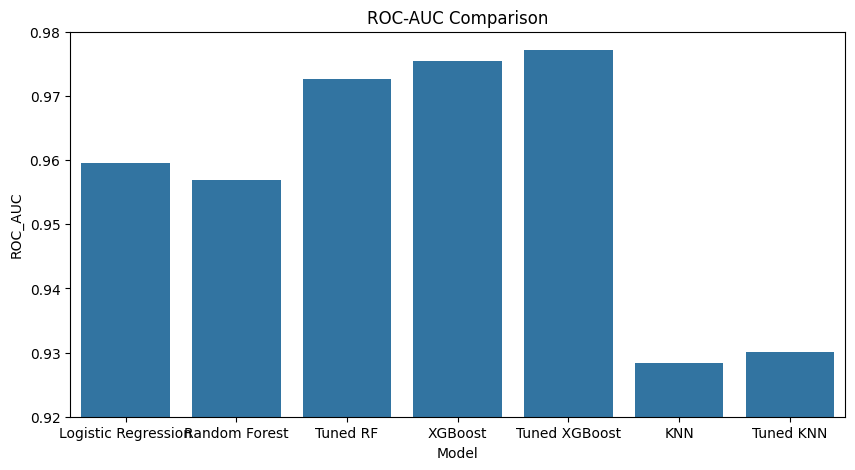

In [98]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Tuned RF',
        'XGBoost',
        'Tuned XGBoost',
        'KNN',
        'Tuned KNN'
    ],
    'ROC_AUC': [
        0.9595,
        0.9569,
        0.9727,
        0.9754,
        0.9772,
        0.9283,
        0.9301
    ]
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x='Model',
    y='ROC_AUC'
)

plt.title('ROC-AUC Comparison')
plt.ylim(0.92, 0.98)

plt.show()

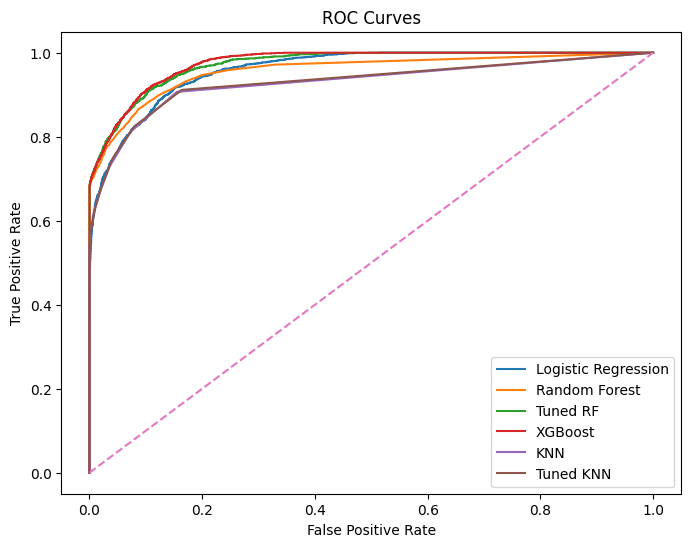

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_rf_prob)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
fpr_txgb, tpr_txgb, _ = roc_curve(y_test, txgb_prob)

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)

fpr_tuned_knn, tpr_tuned_knn, _ = roc_curve(y_test, tuned_knn_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label='Logistic Regression'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest'
)

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label='Tuned RF'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label='XGBoost'
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label='KNN'
)

plt.plot(
    fpr_tuned_knn,
    tpr_tuned_knn,
    label='Tuned KNN'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curves')

plt.legend()

plt.show()

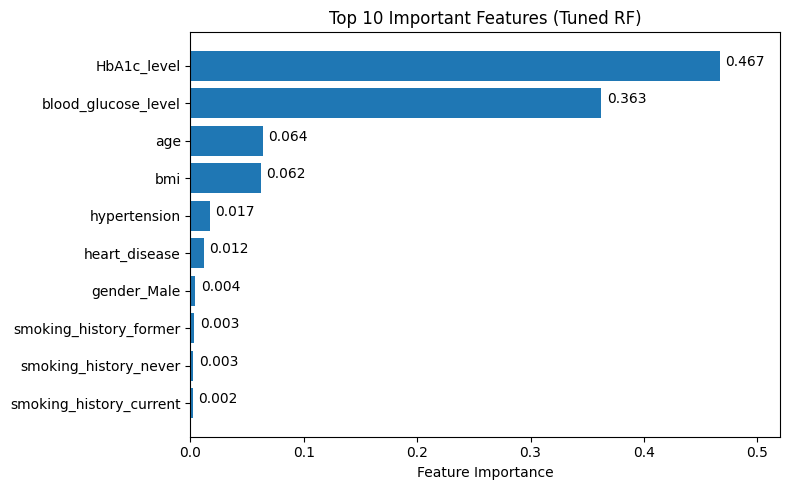

In [82]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': models['tuned_random_forest'].feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
)

top10 = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(
    top10['Feature'][::-1],
    top10['Importance'][::-1]
)

for i, v in enumerate(top10['Importance'][::-1]):
    plt.text(v + 0.005, i, f'{v:.3f}')

plt.xlim(0, 0.52)
plt.xlabel('Feature Importance')
plt.title('Top 10 Important Features (Tuned RF)')
plt.tight_layout()
plt.show()

In [99]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": (lr_y_pred, lr_prob),
    "Random Forest": (rf_y_pred, rf_prob),
    "Tuned RF": (tuned_rf_y_pred, tuned_rf_prob),
    "Tuned RF Balanced": (balance_tuned_rf_y_pred, balance_tuned_rf_prob),
    "Tuned RF Smote": (smote_tuned_rf_y_pred, smote_tuned_rf_prob),
    "XGBoost": (xgb_y_pred, xgb_prob),
    "Tuned XGBoost": (txgb_y_pred, txgb_prob),
    "KNN": (knn_y_pred, knn_prob),
    "Tuned KNN": (tuned_knn_y_pred, tuned_knn_prob)
}

results = []

for name, (y_pred, y_prob) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
6,Tuned XGBoost,0.9714,0.9736,0.6952,0.8111,0.9772
5,XGBoost,0.9706,0.9520,0.7022,0.8083,0.9754
3,Tuned RF Balanced,0.9288,0.5656,0.8337,0.6740,0.9730
2,Tuned RF,0.9722,0.9899,0.6916,0.8143,0.9727
4,Tuned RF Smote,0.9287,0.5648,0.8379,0.6747,0.9726
0,Logistic Regression,0.9588,0.8587,0.6380,0.7321,0.9595
1,Random Forest,0.9695,0.9419,0.6975,0.8015,0.9569
7,KNN,0.9602,0.9550,0.5761,0.7186,0.9283
8,Tuned KNN,0.9586,0.8750,0.6191,0.7251,0.9016


In [92]:
comparison_df["Rank"] = (
    comparison_df["ROC-AUC"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

comparison_df = comparison_df.sort_values("Rank")

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Rank
5,XGBoost,0.9706,0.9520,0.7022,0.8083,0.9754,1
3,Tuned RF Balanced,0.9288,0.5656,0.8337,0.6740,0.9730,2
2,Tuned RF,0.9722,0.9899,0.6916,0.8143,0.9727,3
4,Tuned RF Smote,0.9287,0.5648,0.8379,0.6747,0.9726,4
0,Logistic Regression,0.9588,0.8587,0.6380,0.7321,0.9595,5
1,Random Forest,0.9695,0.9419,0.6975,0.8015,0.9569,6
6,KNN,0.9602,0.9550,0.5761,0.7186,0.9283,7
7,Tuned KNN,0.9586,0.8750,0.6191,0.7251,0.9016,8


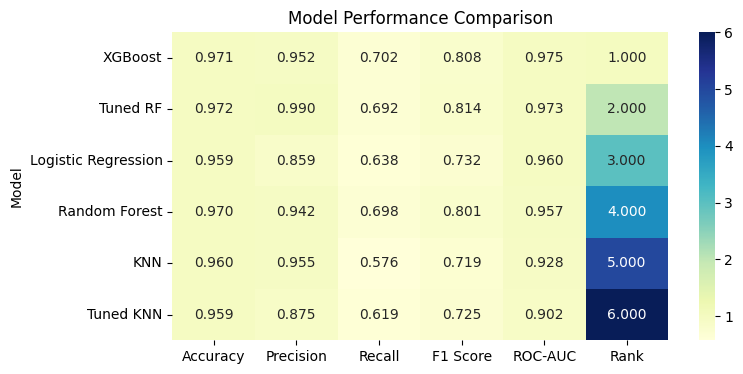

In [70]:
metrics_df = comparison_df.set_index("Model")

plt.figure(figsize=(8,4))
sns.heatmap(
    metrics_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Model Performance Comparison")
plt.show()